Bit data:
[0 0 0 0 1 0 1 1 1 0]
I channel: [-1 -1 -1 -1  1]
Q channel: [-1  1  1  1 -1]


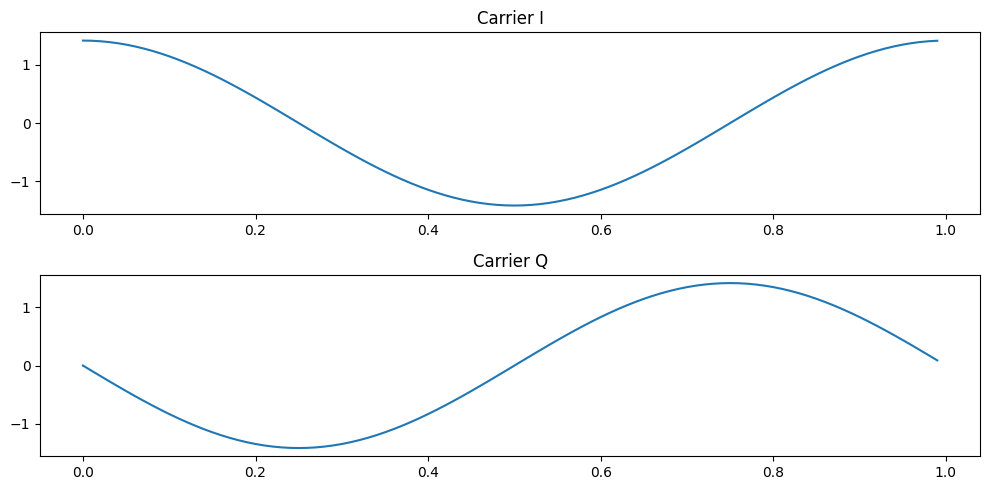

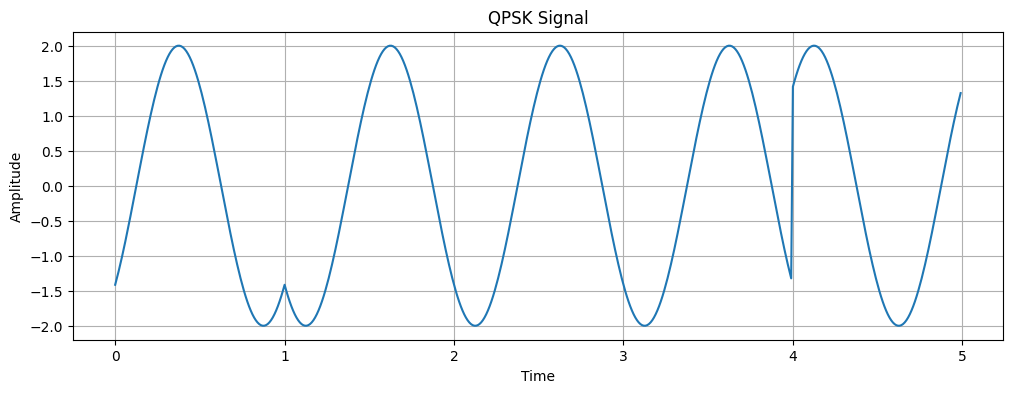

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
jdata = 10          # jumlah bit (harus genap)
T = 1               # periode simbol
jsampel = 100       # jumlah sample
fc = 1 / T          # frekuensi carrier

# Generate bit random
b = np.random.randint(0, 2, jdata)

print("Bit data:")
print(b)

# Serial to Parallel (I dan Q)
sp = b.reshape(2, -1)

# Mapping bipolar: 0 -> -1, 1 -> +1
mapping = 2 * sp - 1

mapI = mapping[0, :]
mapQ = mapping[1, :]

print("I channel:", mapI)
print("Q channel:", mapQ)

# Time vector
t = np.arange(0, T, T/jsampel)

# Carrier
b1 = np.sqrt(2/T) * np.cos(2 * np.pi * fc * t)
b2 = -np.sqrt(2/T) * np.sin(2 * np.pi * fc * t)

# Plot carrier
plt.figure(figsize=(10, 5))

plt.subplot(2,1,1)
plt.plot(t, b1)
plt.title("Carrier I")

plt.subplot(2,1,2)
plt.plot(t, b2)
plt.title("Carrier Q")

plt.tight_layout()
plt.show()

# Generate QPSK signal
QPSK = []

for i in range(len(mapI)):
    sI = mapI[i] * b1
    sQ = mapQ[i] * b2
    
    symbol = sI + sQ
    QPSK.extend(symbol)

QPSK = np.array(QPSK)

# Time axis untuk seluruh sinyal
t_total = np.arange(0, len(QPSK)) * (T/jsampel)

# Plot QPSK signal
plt.figure(figsize=(12,4))
plt.plot(t_total, QPSK)
plt.title("QPSK Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()